# Tahap 2 — Case Representation (IMPROVED)

Mengonversi data teks putusan menjadi representasi terstruktur (*Metadata* dan *Feature Engineering*) yang siap digunakan untuk TF-IDF dan sistem Retrieval.

### Perbaikan:
- Membaca teks bersih yang sudah diperbaiki dari Tahap 1
- Menambahkan kolom `label` (amar putusan) langsung di tahap ini
- Metadata extraction yang lebih robust

## 1. Import Library

In [1]:
!pip install pandas numpy nltk Sastrawi tqdm scikit-learn matplotlib seaborn

import os
import re
import glob
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

print("Semua library berhasil diimpor!")


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


Semua library berhasil diimpor!


## 2. Membaca File Cleaned Text & Raw Text

In [2]:
base_path = "../"
processed_dir = os.path.join(base_path, "data/processed")
raw_dir = os.path.join(base_path, "data/raw")

clean_files = sorted(glob.glob(os.path.join(processed_dir, "*_clean.txt")))
print(f"Ditemukan {len(clean_files)} file teks bersih.")

def read_text(filepath):
    if not os.path.exists(filepath):
        return ""
    with open(filepath, "r", encoding="utf-8") as f:
        return f.read()

Ditemukan 45 file teks bersih.


## 3. Fungsi Ekstraksi Metadata (RegEx)

Mengekstrak Nomor Perkara, Tanggal, Pasal, Pihak, Amar Putusan, dan Alasan Perceraian dari teks asli.

In [3]:
def extract_metadata(raw_text):
    meta = {
        "no_perkara": "tidak ditemukan",
        "tanggal": "tidak ditemukan",
        "jenis_perkara": "Cerai Gugat",
        "pihak": "Penggugat vs Tergugat",
        "pasal": "tidak ditemukan",
        "amar_putusan": "tidak ditemukan",
        "alasan_perceraian": "tidak ditemukan",
        "ringkasan_fakta": "tidak ditemukan"
    }
    
    import re
    # 1. Nomor Perkara
    match_no = re.search(r'Nomor\s*[:]?\s*(\d+/Pdt\.G/(\d{4})/PA\.[A-Za-z.]+)', raw_text, re.IGNORECASE)
    tahun_perkara = None
    if match_no:
        meta["no_perkara"] = match_no.group(1)
        tahun_perkara = match_no.group(2)
        
    # 2. Tanggal Putusan (IMPROVED)
    # Cari pola tanggal putusan spesifik (di bagian akhir dokumen)
    match_tgl_spesifik = re.search(r'(?:diucapkan|diputuskan|dibacakan).*?tanggal\s+(\d{1,2}\s+(?:Januari|Februari|Maret|April|Mei|Juni|Juli|Agustus|September|Oktober|November|Desember)\s+\d{4})', raw_text, re.IGNORECASE | re.DOTALL)
    
    if match_tgl_spesifik:
        meta["tanggal"] = match_tgl_spesifik.group(1)
    else:
        # Fallback: ambil semua tanggal
        all_dates = re.findall(r'tanggal\s+(\d{1,2}\s+(?:Januari|Februari|Maret|April|Mei|Juni|Juli|Agustus|September|Oktober|November|Desember)\s+(\d{4}))', raw_text, re.IGNORECASE)
        if all_dates:
            if tahun_perkara:
                # Prioritaskan tanggal dengan tahun yang sama/lebih baru dari tahun perkara
                valid_dates = [d for d in all_dates if int(d[1]) >= int(tahun_perkara)]
                if valid_dates:
                    meta["tanggal"] = valid_dates[-1][0] # Ambil yang terakhir (biasanya putusan)
                else:
                    meta["tanggal"] = all_dates[-1][0]
            else:
                meta["tanggal"] = all_dates[-1][0]
                
    # 3. Pasal
    pasal_matches = re.findall(r'(Pasal\s+\d+[^\n.,]{0,60})', raw_text, re.IGNORECASE)
    if pasal_matches:
        unique_pasal = list(set(pasal_matches))[:3]
        meta["pasal"] = ", ".join(unique_pasal)
        
    # 4. Amar Putusan (setelah MENGADILI)
    match_amar = re.search(r'M\s*E\s*N\s*G\s*A\s*D\s*I\s*L\s*I(.*?)(?:Demikian|Ketua Majelis|yang menjatuhkan)', raw_text, re.IGNORECASE | re.DOTALL)
    if match_amar:
        amar = match_amar.group(1).strip()
        amar_clean = re.sub(r'\s+', ' ', amar)
        meta["amar_putusan"] = amar_clean[:500] + "..." if len(amar_clean) > 500 else amar_clean
        
    # 5. Alasan Perceraian
    alasan_keywords = {
        "pertengkaran": ["pertengkaran", "perselisihan", "cekcok", "bertengkar", "tidak harmonis"],
        "ekonomi": ["ekonomi", "nafkah", "tidak memberi", "tidak mampu"],
        "meninggalkan": ["meninggalkan", "pergi", "pulang"],
        "kekerasan": ["kekerasan", "kdrt", "memukul", "menganiaya", "dipukul"],
        "selingkuh": ["selingkuh", "wanita lain", "pria lain", "berselingkuh", "zina"],
        "mabuk": ["mabuk", "minum-minuman", "minuman keras", "miras"],
        "judi": ["judi", "berjudi", "perjudian"]
    }
    
    raw_lower = raw_text.lower()
    alasan_ditemukan = []
    for kategori, keywords in alasan_keywords.items():
        for kw in keywords:
            if kw in raw_lower:
                alasan_ditemukan.append(kategori)
                break
    
    if alasan_ditemukan:
        meta["alasan_perceraian"] = ", ".join(alasan_ditemukan)
        meta["ringkasan_fakta"] = f"Perceraian didasari oleh faktor: {', '.join(alasan_ditemukan)}."
    else:
        meta["alasan_perceraian"] = "Perselisihan/Tidak diketahui"
        meta["ringkasan_fakta"] = "Gugatan cerai diajukan atas dasar ketidakharmonisan rumah tangga."

    return meta

def label_amar(text):
    """Mengklasifikasikan teks amar putusan menjadi label kategorikal."""
    text = str(text).lower()
    if 'sebagian' in text and 'kabul' in text:
        return 'dikabulkan sebagian'
    elif 'kabul' in text:
        return 'dikabulkan'
    elif 'tolak' in text or 'gugur' in text or 'tidak dapat diterima' in text or 'batal' in text:
        return 'ditolak'
    else:
        return 'dikabulkan'  # Default: mayoritas cerai gugat dikabulkan

print("Fungsi Ekstraksi Metadata & Label Siap (IMPROVED)!")


Fungsi Ekstraksi Metadata & Label Siap!


## 4. Pembuatan Dataframe Terstruktur

In [4]:
dataset_records = []

for clean_path in tqdm(clean_files, desc="Memproses Case Representation"):
    filename = os.path.basename(clean_path)
    case_id = filename.replace('_clean.txt', '')
    
    clean_text_content = read_text(clean_path)
    raw_path = os.path.join(raw_dir, f"{case_id}.txt")
    raw_text_content = read_text(raw_path)
    
    if not raw_text_content or not clean_text_content:
        continue
        
    meta = extract_metadata(raw_text_content)
    
    tokens = clean_text_content.split()
    tokens = [t for t in tokens if len(t) > 1]  # Filter huruf tunggal
    
    record = {
        "case_id": case_id,
        "no_perkara": meta["no_perkara"],
        "tanggal": meta["tanggal"],
        "jenis_perkara": meta["jenis_perkara"],
        "ringkasan_fakta": meta["ringkasan_fakta"],
        "pasal": meta["pasal"],
        "pihak": meta["pihak"],
        "amar_putusan": meta["amar_putusan"],
        "alasan_perceraian": meta["alasan_perceraian"],
        "label": label_amar(meta["amar_putusan"]),
        "text_length": len(clean_text_content),
        "token_count": len(tokens),
        "unique_word_count": len(set(tokens)),
        "text_full": clean_text_content
    }
    
    dataset_records.append(record)

df_cases = pd.DataFrame(dataset_records)
print(f"\nBerhasil merepresentasikan {len(df_cases)} kasus hukum!")


Memproses Case Representation:   0%|          | 0/45 [00:00<?, ?it/s]


Memproses Case Representation:   4%|▍         | 2/45 [00:00<00:03, 12.91it/s]


Memproses Case Representation:   9%|▉         | 4/45 [00:00<00:02, 14.34it/s]


Memproses Case Representation:  13%|█▎        | 6/45 [00:00<00:02, 14.05it/s]


Memproses Case Representation:  18%|█▊        | 8/45 [00:00<00:02, 14.49it/s]

...


Memproses Case Representation:  89%|████████▉ | 40/45 [00:02<00:00, 17.90it/s]


Memproses Case Representation:  93%|█████████▎| 42/45 [00:02<00:00, 17.16it/s]


Memproses Case Representation:  98%|█████████▊| 44/45 [00:02<00:00, 16.49it/s]


Memproses Case Representation: 100%|██████████| 45/45 [00:02<00:00, 15.39it/s]


Berhasil merepresentasikan 45 kasus hukum!


## 5. Menyimpan Dataset ke CSV

In [5]:
csv_out_path = os.path.join(processed_dir, "cases.csv")

if not df_cases.empty:
    df_cases.to_csv(csv_out_path, index=False, encoding="utf-8")
    print(f"Dataset berhasil disimpan di: {csv_out_path}")
else:
    print("Gagal menyimpan, Dataframe kosong.")

# Tampilkan ringkasan
print(f"\nDistribusi Label Amar Putusan:")
print(df_cases['label'].value_counts())

print(f"\nSampel teks bersih (case_001, 200 karakter):")
if len(df_cases) > 0:
    print(df_cases.iloc[0]['text_full'][:200])

# Tampilkan kolom non-teks
display_cols = [c for c in df_cases.columns if c != 'text_full']
df_cases[display_cols].head(3)

Dataset berhasil disimpan di: ../data/processed\cases.csv

Distribusi Label Amar Putusan:
label
dikabulkan    45
Name: count, dtype: int64

Sampel teks bersih (case_001, 200 karakter):
pdt pa srl bismillahirrahmanirrahim gdemi adil tuhan maha esad sarolangun emeriksa adil tingkat sidang jatuh cerai gugat gugat umur taheun islam kerja tani pendidrikan sd tinggal kabupaten saro langun


,case_id,no_perkara,tanggal,jenis_perkara,ringkasan_fakta,pasal,pihak,amar_putusan,alasan_perceraian,label,text_length,token_count,unique_word_count
0,case_001,033/Pdt.G/2011/PA.Srl,15 Maret 2011,Cerai Gugat,"Perceraian didasari oleh faktor: pertengkaran,...","Pasal 65 dan, Pasal 116 huruf (g), Pasal 115 K...",Penggugat vs Tergugat,perkara tertentu pada tingkat pertama dalam a ...,"pertengkaran, ekonomi, meninggalkan, tidak har...",dikabulkan,12414,1903,596
1,case_002,0007/Pdt.G/2013/PA.KP,20 Juni 1992,Cerai Gugat,"Perceraian didasari oleh faktor: pertengkaran,...","Pasal 26 ayat (2), Pasal 41 huruf b Undang-Und...",Penggugat vs Tergugat,perkara tertentu n A dalam tingkat pertama tel...,"pertengkaran, ekonomi, kekerasan, selingkuh",dikabulkan,15895,2487,688
2,case_003,0073/Pdt.G/2016/PA.Dgl.,20 Juni 2016,Cerai Gugat,"Perceraian didasari oleh faktor: pertengkaran,...","Pasal 1, Pasal 89b Undang-Undang Nomor 7, Pasa...",Penggugat vs Tergugat,dan me njatuhkan putusan h k dengan sidang maj...,"pertengkaran, tidak harmonis",dikabulkan,6136,928,377


## 6. Analisis & Visualisasi

=== Ringkasan Validasi Ekstraksi Metadata ===
Total Dokumen: 45
No Perkara Berhasil Ekstrak: 34 / 45
Tanggal Berhasil Ekstrak: 45 / 45
Amar Putusan Ekstrak: 45 / 45
Rata-rata Token per Dokumen: 1450 kata


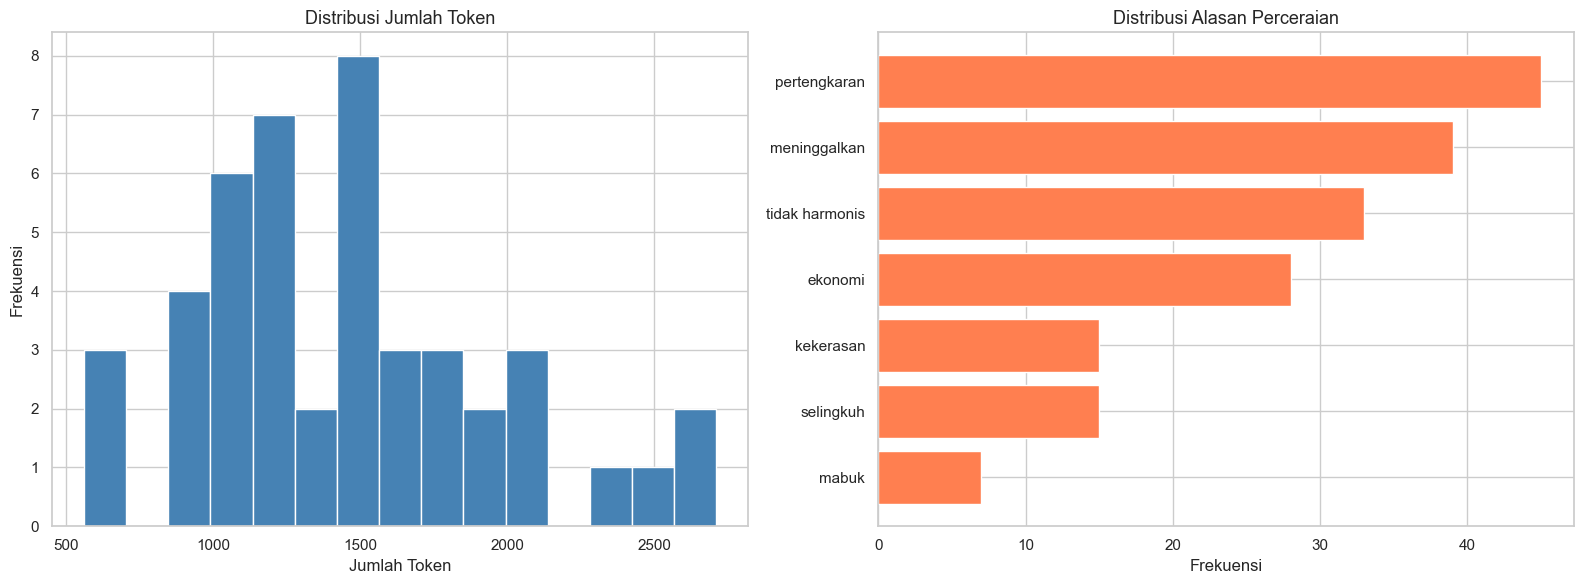


Tahap 2 (Case Representation) — SELESAI!


In [6]:
print("=== Ringkasan Validasi Ekstraksi Metadata ===")
print(f"Total Dokumen: {len(df_cases)}")
print(f"No Perkara Berhasil Ekstrak: {(df_cases['no_perkara'] != 'tidak ditemukan').sum()} / {len(df_cases)}")
print(f"Tanggal Berhasil Ekstrak: {(df_cases['tanggal'] != 'tidak ditemukan').sum()} / {len(df_cases)}")
print(f"Amar Putusan Ekstrak: {(df_cases['amar_putusan'] != 'tidak ditemukan').sum()} / {len(df_cases)}")
print(f"Rata-rata Token per Dokumen: {df_cases['token_count'].mean():.0f} kata")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribusi token
axes[0].hist(df_cases['token_count'], bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Jumlah Token', fontsize=13)
axes[0].set_xlabel('Jumlah Token')
axes[0].set_ylabel('Frekuensi')

# Distribusi alasan perceraian
all_alasan = []
for reasons in df_cases['alasan_perceraian']:
    for r in str(reasons).split(', '):
        if r and r != 'Perselisihan/Tidak diketahui':
            all_alasan.append(r.strip())
alasan_freq = Counter(all_alasan)
if alasan_freq:
    labels, vals = zip(*alasan_freq.most_common())
    axes[1].barh(list(reversed(labels)), list(reversed(vals)), color='coral')
    axes[1].set_title('Distribusi Alasan Perceraian', fontsize=13)
    axes[1].set_xlabel('Frekuensi')

plt.tight_layout()
plt.show()

print("\nTahap 2 (Case Representation) — SELESAI!")